In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

# Database connection
DB_URL = f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
engine = create_engine(DB_URL)

# Load clean data
df = pd.read_sql("SELECT * FROM clean_fruits ORDER BY fruit_id", engine)

print(f"Loaded {len(df)} fruits")
df.head()

Loaded 49 fruits


,fruit_id,name,family,calories,sugar,carbohydrates,protein,fat,updated_at
0,1,Banana,Musaceae,96.0,17.2,22.0,1.0,0.2,2026-08-07 19:53:37.275194
1,2,Orange,Rutaceae,43.0,8.2,8.3,1.0,0.2,2026-08-07 19:53:37.275194
2,3,Strawberry,Rosaceae,29.0,5.4,5.5,0.8,0.4,2026-08-07 19:53:37.275194
3,4,Pear,Rosaceae,57.0,10.0,15.0,0.4,0.1,2026-08-07 19:53:37.275194
4,5,Tomato,Solanaceae,74.0,2.6,3.9,0.9,0.2,2026-08-07 19:53:37.275194


In [41]:
# Dataset overview
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")

# Statistical summary
print("\n" + "=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
numeric_cols = ['calories', 'sugar', 'carbohydrates', 'protein', 'fat']
print(df[numeric_cols].describe())

DATASET OVERVIEW
Shape: (49, 9)

Columns: ['fruit_id', 'name', 'family', 'calories', 'sugar', 'carbohydrates', 'protein', 'fat', 'updated_at']

Missing values:
fruit_id         0
name             0
family           0
calories         0
sugar            0
carbohydrates    0
protein          0
fat              0
updated_at       0
dtype: int64

Data types:
fruit_id                  int64
name                     object
family                   object
calories                float64
sugar                   float64
carbohydrates           float64
protein                 float64
fat                     float64
updated_at       datetime64[ns]
dtype: object

STATISTICAL SUMMARY
         calories      sugar  carbohydrates    protein        fat
count   49.000000  49.000000      49.000000  49.000000  49.000000
mean    68.510204   7.990408      12.152857   1.368163   2.005102
std     86.454256   4.907164       5.661771   2.367021   8.872052
min     15.000000   0.000000       3.100000   0.000000  

In [42]:
# Check for duplicates
duplicates = df.duplicated(subset=['fruit_id']).sum()
print(f"Duplicate fruit_ids: {duplicates}")

# Check for duplicate fruit names
name_duplicates = df['name'].duplicated().sum()
if name_duplicates > 0:
    print(f"Found {name_duplicates} duplicate fruit names")
    print(df[df['name'].duplicated(keep=False)][['fruit_id', 'name']])
else:
    print("No duplicate fruit names found")

Duplicate fruit_ids: 0
No duplicate fruit names found


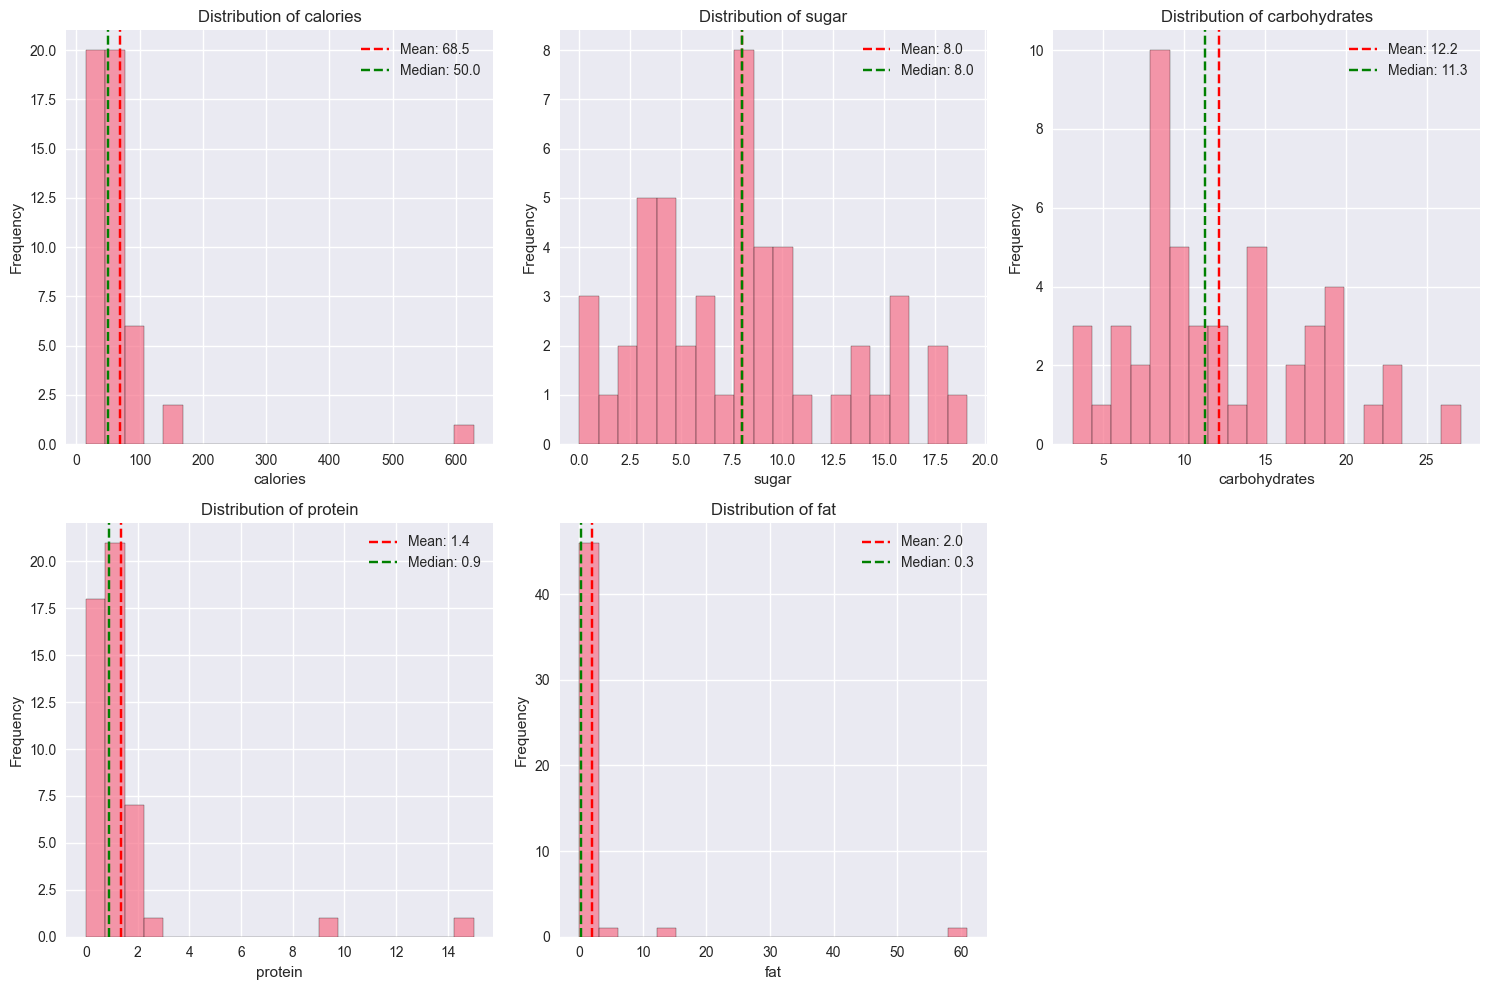

In [43]:
# Histograms for numeric columns
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    if col in df.columns:
        axes[idx].hist(df[col].dropna(), bins=20, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')

        # Add mean and median lines
        mean_val = df[col].mean()
        median_val = df[col].median()
        axes[idx].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
        axes[idx].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.1f}')
        axes[idx].legend()

# Remove empty subplot
axes[5].axis('off')
plt.tight_layout()
plt.show()

FRUIT FAMILY DISTRIBUTION
family
Rosaceae           11
Rutaceae            5
Cucurbitaceae       4
Moraceae            3
Cactaceae           2
Myrtaceae           2
Ericaceae           2
Actinidiaceae       2
Musaceae            1
Annonaceae          1
 Ebenaceae          1
Clusiaceae          1
Betulaceae          1
Lauraceae           1
Vitaceae            1
Lythraceae          1
Sapindaceae         1
Passifloraceae      1
Grossulariaceae     1
Malvaceae           1
Ebenaceae           1
Caricaceae          1
Anacardiaceae       1
Bromeliaceae        1
Solanaceae          1
Salicaceae          1
Name: count, dtype: int64


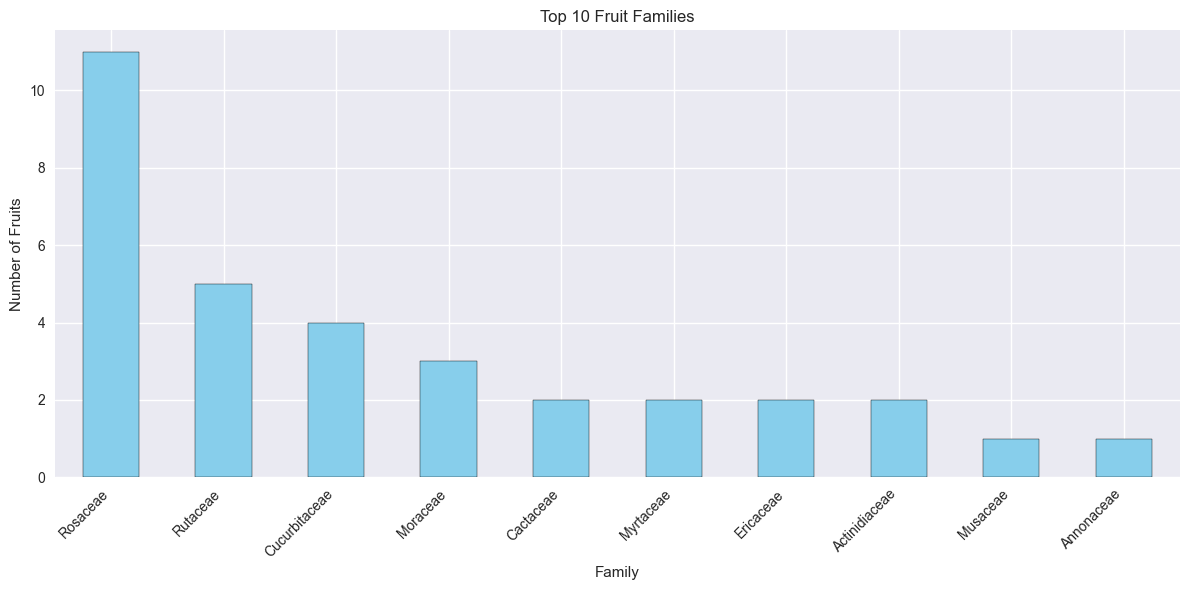

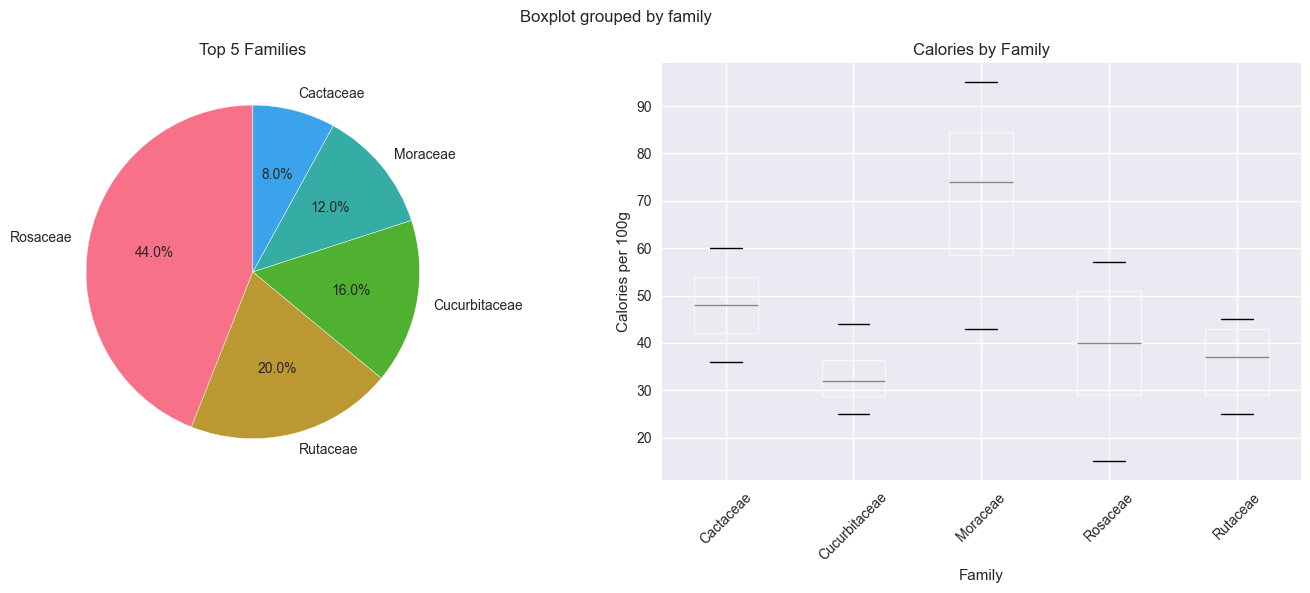

In [44]:
# Family distribution
family_counts = df['family'].value_counts()
print("=" * 50)
print("FRUIT FAMILY DISTRIBUTION")
print("=" * 50)
print(family_counts)

# Bar chart for top families
plt.figure(figsize=(12, 6))
family_counts.head(10).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 Fruit Families')
plt.xlabel('Family')
plt.ylabel('Number of Fruits')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Pie chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
family_counts.head(5).plot(kind='pie', ax=ax1, autopct='%1.1f%%', startangle=90)
ax1.set_title('Top 5 Families')
ax1.set_ylabel('')

# Box plot of calories by family
top_families = family_counts.head(5).index
df_top_families = df[df['family'].isin(top_families)]
df_top_families.boxplot(column='calories', by='family', ax=ax2)
ax2.set_title('Calories by Family')
ax2.set_xlabel('Family')
ax2.set_ylabel('Calories per 100g')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

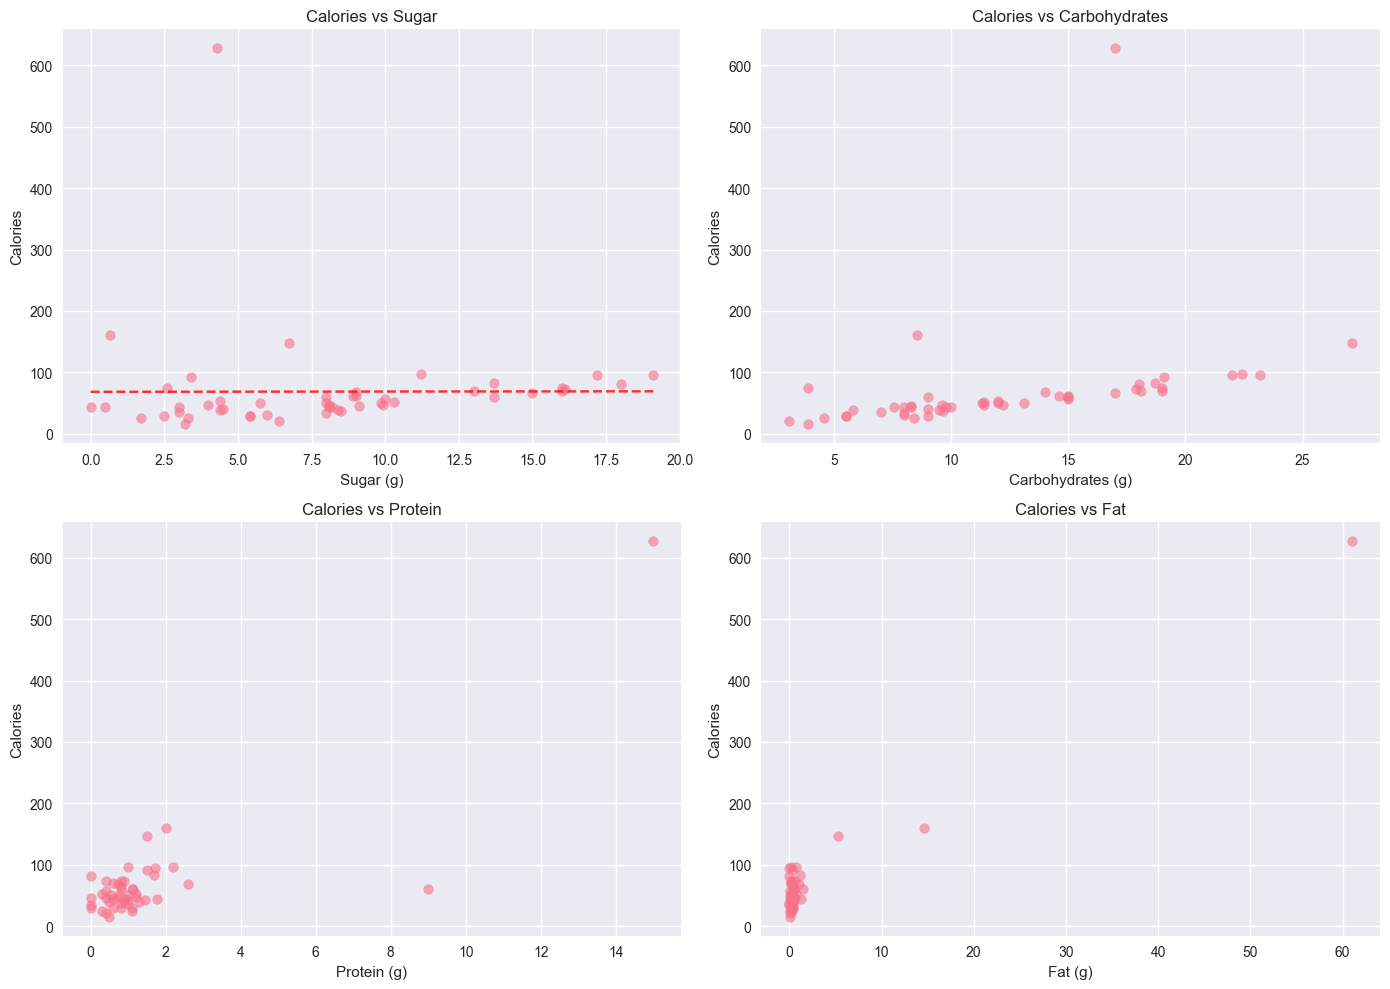

In [45]:
# Create scatter plots for key relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Calories vs Sugar
axes[0].scatter(df['sugar'], df['calories'], alpha=0.6)
axes[0].set_xlabel('Sugar (g)')
axes[0].set_ylabel('Calories')
axes[0].set_title('Calories vs Sugar')
# Add trend line
z = np.polyfit(df['sugar'].dropna(), df['calories'].dropna(), 1)
p = np.poly1d(z)
axes[0].plot(df['sugar'].sort_values(), p(df['sugar'].sort_values()), "r--", alpha=0.8)

# Calories vs Carbohydrates
axes[1].scatter(df['carbohydrates'], df['calories'], alpha=0.6)
axes[1].set_xlabel('Carbohydrates (g)')
axes[1].set_ylabel('Calories')
axes[1].set_title('Calories vs Carbohydrates')

# Calories vs Protein
axes[2].scatter(df['protein'], df['calories'], alpha=0.6)
axes[2].set_xlabel('Protein (g)')
axes[2].set_ylabel('Calories')
axes[2].set_title('Calories vs Protein')

# Calories vs Fat
axes[3].scatter(df['fat'], df['calories'], alpha=0.6)
axes[3].set_xlabel('Fat (g)')
axes[3].set_ylabel('Calories')
axes[3].set_title('Calories vs Fat')

plt.tight_layout()
plt.show()

In [46]:
# Find most extreme examples
print("=" * 50)
print("FRUIT NUTRITION LEADERS")
print("=" * 50)

print("\nHighest Calories:")
print(df[['name', 'family', 'calories']].sort_values('calories', ascending=False).head(10))

print("\nHighest Sugar:")
print(df[['name', 'family', 'sugar']].sort_values('sugar', ascending=False).head(10))

print("\nHighest Protein:")
print(df[['name', 'family', 'protein']].sort_values('protein', ascending=False).head(10))

print("\nHighest Fat:")
print(df[['name', 'family', 'fat']].sort_values('fat', ascending=False).head(10))

print("\nLowest Calories:")
print(df[['name', 'family', 'calories']].sort_values('calories').head(10))

FRUIT NUTRITION LEADERS

Highest Calories:
            name          family  calories
42      Hazelnut      Betulaceae     628.0
36       Avocado       Lauraceae     160.0
19        Durian       Malvaceae     147.0
26  Passionfruit  Passifloraceae      97.0
0         Banana        Musaceae      96.0
40     Jackfruit        Moraceae      95.0
47        Annona      Annonaceae      92.0
32   Pomegranate      Lythraceae      83.0
18     Persimmon       Ebenaceae      81.0
24           Fig        Moraceae      74.0

Highest Sugar:
                  name         family  sugar
40           Jackfruit       Moraceae  19.10
18           Persimmon      Ebenaceae  18.00
0               Banana       Musaceae  17.20
44          Mangosteen     Clusiaceae  16.11
34               Grape       Vitaceae  16.00
24                 Fig       Moraceae  16.00
23              Lychee    Sapindaceae  15.00
32         Pomegranate     Lythraceae  13.70
11               Mango  Anacardiaceae  13.70
46  Japanese Persi

In [47]:
# Aggregate by family
family_stats = df.groupby('family')[numeric_cols].agg(['mean', 'std', 'count'])
print("=" * 50)
print("AVERAGE NUTRITION BY FAMILY")
print("=" * 50)
print(family_stats)

# Find the family with highest average calories
top_family_calories = df.groupby('family')['calories'].mean().sort_values(ascending=False).head(5)
print("\nTop 5 Families by Average Calories:")
print(top_family_calories)

AVERAGE NUTRITION BY FAMILY
                   calories                       sugar                  \
                       mean        std count       mean       std count   
family                                                                    
 Ebenaceae        70.000000        NaN     1  13.000000       NaN     1   
Actinidiaceae     61.000000   0.000000     2   8.950000  0.070711     2   
Anacardiaceae     60.000000        NaN     1  13.700000       NaN     1   
Annonaceae        92.000000        NaN     1   3.400000       NaN     1   
Betulaceae       628.000000        NaN     1   4.300000       NaN     1   
Bromeliaceae      50.000000        NaN     1   9.850000       NaN     1   
Cactaceae         48.000000  16.970563     2   5.500000  3.535534     2   
Caricaceae        39.000000        NaN     1   4.400000       NaN     1   
Clusiaceae        73.000000        NaN     1  16.110000       NaN     1   
Cucurbitaceae     33.250000   8.057088     4   4.450000  3.262412     4 

In [48]:
# Generate EDA Summary
print("=" * 80)
print("EDA SUMMARY - PLAIN ENGLISH")
print("=" * 80)

summary = f"""
Data Overview:
- Total fruits in dataset: {len(df)}
- Number of distinct fruit families: {df['family'].nunique()}
- Most common family: {df['family'].mode()[0]} ({family_counts.max()} fruits)

Key Nutritional Insights:
1. Calories range from {df['calories'].min():.1f} to {df['calories'].max():.1f} kcal per 100g
2. Average calories: {df['calories'].mean():.1f} kcal
3. Sugar content varies from {df['sugar'].min():.1f} to {df['sugar'].max():.1f}g per 100g
4. Highest calorie fruit: {df.loc[df['calories'].idxmax(), 'name']} ({df['calories'].max():.1f} kcal)
5. Lowest calorie fruit: {df.loc[df['calories'].idxmin(), 'name']} ({df['calories'].min():.1f} kcal)

Key Relationships (Observation):
- From the scatter plots, we can see that sugar and carbohydrates have the strongest positive relationship with calories
- Fruits with higher sugar content tend to have more calories
- Protein and fat show weaker relationships with calories

Family Insights:
- {top_family_calories.index[0]} family has the highest average calories ({top_family_calories.iloc[0]:.1f} kcal)
- The most diverse family is {df['family'].mode()[0]} with {family_counts.max()} different fruits
"""

print(summary)

# Save summary to file
with open('../data/eda_summary.txt', 'w') as f:
    f.write(summary)
print("\nSummary saved to data/eda_summary.txt")

EDA SUMMARY - PLAIN ENGLISH

Data Overview:
- Total fruits in dataset: 49
- Number of distinct fruit families: 26
- Most common family: Rosaceae (11 fruits)

Key Nutritional Insights:
1. Calories range from 15.0 to 628.0 kcal per 100g
2. Average calories: 68.5 kcal
3. Sugar content varies from 0.0 to 19.1g per 100g
4. Highest calorie fruit: Hazelnut (628.0 kcal)
5. Lowest calorie fruit: Apricot (15.0 kcal)

Key Relationships (Observation):
- From the scatter plots, we can see that sugar and carbohydrates have the strongest positive relationship with calories
- Fruits with higher sugar content tend to have more calories
- Protein and fat show weaker relationships with calories

Family Insights:
- Betulaceae family has the highest average calories (628.0 kcal)
- The most diverse family is Rosaceae with 11 different fruits


Summary saved to data/eda_summary.txt
